#### Import Libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten



#### Load Fashion‑MNIST Dataset

In [6]:
#!pip install idx2numpy


In [2]:

import idx2numpy

(X_train, y_train), (X_test, y_test) = (
    (idx2numpy.convert_from_file("I:/DS/DL for teens/session12/dataset/archive/train-images-idx3-ubyte"),
     idx2numpy.convert_from_file("I:/DS/DL for teens/session12/dataset/archive/train-labels-idx1-ubyte")),
    (idx2numpy.convert_from_file("I:/DS/DL for teens/session12/dataset/archive/t10k-images-idx3-ubyte"),
     idx2numpy.convert_from_file("I:/DS/DL for teens/session12/dataset/archive/t10k-labels-idx1-ubyte"))
)


In [3]:
# (X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
# (X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()


X_train = X_train / 255.0
X_test  = X_test / 255.0


#### Visualize a Sample

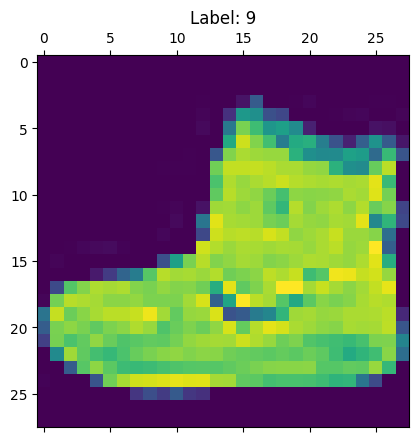

In [4]:
plt.matshow(X_train[0])
plt.title(f"Label: {y_train[0]}")
plt.show()


#### Build & Train the Model

In [5]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=1)


G:\DS\ML for teens\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.8253 - loss: 0.4957


In [6]:
model.evaluate(X_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8405 - loss: 0.4466


[0.44662630558013916, 0.840499997138977]

In [7]:
model.evaluate(X_train, y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8551 - loss: 0.3996


[0.39961618185043335, 0.8551333546638489]

#### Save the Model

In [8]:
# Save in Keras 3 format (works with load_model)
model.save("my_mnist_model.keras")
# model.export("./saved_model")

### Post‑Training Quantization

##### A) Convert without quantization

In [9]:
# converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
# converter = tf.lite.TFLiteConverter.from_saved_model("my_mnist_model.keras")

loaded_model = tf.keras.models.load_model("my_mnist_model.keras")
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
tflite_fp32 = converter.convert()

with open("model_fp32.tflite", "wb") as f:
    f.write(tflite_fp32)


INFO:tensorflow:Assets written to: C:\Users\LENOVO\AppData\Local\Temp\tmpburoiera\assets


INFO:tensorflow:Assets written to: C:\Users\LENOVO\AppData\Local\Temp\tmpburoiera\assets


Saved artifact at 'C:\Users\LENOVO\AppData\Local\Temp\tmpburoiera'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2417779417616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2417779415696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2417779416464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2417779415504: TensorSpec(shape=(), dtype=tf.resource, name=None)


##### B) Convert with quantization

In [10]:
loaded_model = tf.keras.models.load_model("my_mnist_model.keras")
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
# converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_int8 = converter.convert()

with open("model_int8.tflite", "wb") as f:
    f.write(tflite_int8)


INFO:tensorflow:Assets written to: C:\Users\LENOVO\AppData\Local\Temp\tmpyf8ugd0e\assets


INFO:tensorflow:Assets written to: C:\Users\LENOVO\AppData\Local\Temp\tmpyf8ugd0e\assets


Saved artifact at 'C:\Users\LENOVO\AppData\Local\Temp\tmpyf8ugd0e'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2416296411408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2416296412944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2416296412560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2416296411600: TensorSpec(shape=(), dtype=tf.resource, name=None)


##### C) Compare model sizes

In [11]:
len(tflite_fp32), len(tflite_int8)


(409688, 106552)

####   Quantization‑Aware Training (QAT)

In [13]:
#!pip install tensorflow-model-optimization


In [12]:
from tensorflow_model_optimization.python.core.keras.compat import keras
import tensorflow_model_optimization as tfmot

# SAME MODEL AS YOUR OLD CODE
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10)
])

model.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=1, validation_split=0.1)

# QAT (old API, now works)
quantize_model = tfmot.quantization.keras.quantize_model
qat_model = quantize_model(model)

qat_model.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

qat_model.summary()


1688/1688 [==============================] - 9s 4ms/step - loss: 0.5600 - accuracy: 0.8059 - val_loss: 0.4962 - val_accuracy: 0.8208
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 28, 28)            3         
 yer)                                                            
                                                                 
 quant_flatten (QuantizeWra  (None, 784)               1         
 pperV2)                                                         
                                                                 
 quant_dense (QuantizeWrapp  (None, 32)                25125     
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 10)                335       
 pperV2)                                               

In [13]:
qat_model.fit(
    X_train,
    y_train,
    epochs=1,
    validation_split=0.1
)


1688/1688 [==============================] - 19s 9ms/step - loss: 0.4235 - accuracy: 0.8508 - val_loss: 0.3934 - val_accuracy: 0.8602


In [21]:
qat_model.evaluate(X_test, y_test)

313/313 [==============================] - 0s 1ms/step - loss: 0.4118 - accuracy: 0.8554


[0.41182398796081543, 0.855400025844574]

In [14]:
converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_qaware_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\LENOVO\AppData\Local\Temp\tmpau48xf9x\assets


INFO:tensorflow:Assets written to: C:\Users\LENOVO\AppData\Local\Temp\tmpau48xf9x\assets
G:\DS\ML for teens\venv\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [15]:
len(tflite_qaware_model)

28224

In [16]:
with open("tflite_qaware_model.tflite", 'wb') as f:
    f.write(tflite_qaware_model)